# **22MIS0103 DIVYA V**

# **BASE CODE — Deutsch–Jozsa algorithm**

In [ ]:
!pip install qiskit qiskit_aer matplotlib

# ---------- IMPORTS ----------
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

# ---------- ORACLES ----------
def oracle_constant(qc, ancilla, value=0):
    """Constant oracle: f(x)=0 or f(x)=1"""
    if value == 1:
        qc.x(ancilla)

def oracle_balanced_parity(qc, inputs, ancilla):
    """Balanced oracle: f(x) = x0 XOR x1 XOR ... XOR xn"""
    for q in inputs:
        qc.cx(q, ancilla)

# ---------- DEUTSCH–JOZSA CIRCUIT ----------
def deutsch_jozsa_circuit(n, oracle_func, *oracle_args):
    qreg = QuantumRegister(n + 1, "q")
    creg = ClassicalRegister(n, "c")
    qc = QuantumCircuit(qreg, creg)

    inputs = list(range(n))
    ancilla = n

    # Step 1: Initialize |0...0>|1>
    qc.x(ancilla)

    # Step 2: Apply Hadamard to all qubits
    qc.h(qreg)

    # 🌟 BLOCH VISUALIZATION after Hadamard
    state_after_h = Statevector.from_instruction(qc)
    print("\n🌀 Bloch sphere after Hadamard:")
    plot_bloch_multivector(state_after_h)
    plt.show()

    # Step 3: Oracle
    oracle_func(qc, *oracle_args)

    # 🌟 BLOCH VISUALIZATION after Oracle
    state_after_oracle = Statevector.from_instruction(qc)
    print("\n🌀 Bloch sphere after Oracle:")
    plot_bloch_multivector(state_after_oracle)
    plt.show()

    # Step 4: Apply Hadamard to input qubits
    for q in inputs:
        qc.h(q)

    # Step 5: Measure input qubits
    qc.measure(inputs, creg)
    return qc

# ---------- EXECUTION ----------
def run_dj(qc):
    simulator = AerSimulator()
    tqc = transpile(qc, simulator)
    job = simulator.run(tqc, shots=1024)
    result = job.result()
    counts = result.get_counts()

    print("Measurement counts:", counts)
    plot_histogram(counts)
    plt.show()

    n = qc.num_clbits
    if counts.get("0" * n, 0) == 1024:
        print("✅ Function is CONSTANT")
    else:
        print("✅ Function is BALANCED")

# ---------- MAIN ----------
if __name__ == "__main__":
    n = 3  # number of input qubits

    print("\n=== Constant Oracle (f(x)=0) ===")
    qc_const = deutsch_jozsa_circuit(n, oracle_constant, n, 0)
    print(qc_const.draw(fold=-1))
    run_dj(qc_const)

    print("\n=== Balanced Oracle (Parity) ===")
    qc_balanced = deutsch_jozsa_circuit(n, oracle_balanced_parity, list(range(n)), n)
    print(qc_balanced.draw(fold=-1))
    run_dj(qc_balanced)



=== Constant Oracle (f(x)=0) ===

🌀 Bloch sphere after Hadamard:

🌀 Bloch sphere after Oracle:
     ┌───┐┌───┐┌─┐      
q_0: ┤ H ├┤ H ├┤M├──────
     ├───┤├───┤└╥┘┌─┐   
q_1: ┤ H ├┤ H ├─╫─┤M├───
     ├───┤├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├┤ H ├─╫──╫─┤M├
     ├───┤├───┤ ║  ║ └╥┘
q_3: ┤ X ├┤ H ├─╫──╫──╫─
     └───┘└───┘ ║  ║  ║ 
c: 3/═══════════╩══╩══╩═
                0  1  2 
Measurement counts: {'000': 1024}
✅ Function is CONSTANT

=== Balanced Oracle (Parity) ===

🌀 Bloch sphere after Hadamard:

🌀 Bloch sphere after Oracle:
     ┌───┐          ┌───┐     ┌─┐           
q_0: ┤ H ├───────■──┤ H ├─────┤M├───────────
     ├───┤       │  └───┘┌───┐└╥┘     ┌─┐   
q_1: ┤ H ├───────┼────■──┤ H ├─╫──────┤M├───
     ├───┤       │    │  └───┘ ║ ┌───┐└╥┘┌─┐
q_2: ┤ H ├───────┼────┼────■───╫─┤ H ├─╫─┤M├
     ├───┤┌───┐┌─┴─┐┌─┴─┐┌─┴─┐ ║ └───┘ ║ └╥┘
q_3: ┤ X ├┤ H ├┤ X ├┤ X ├┤ X ├─╫───────╫──╫─
     └───┘└───┘└───┘└───┘└───┘ ║       ║  ║ 
c: 3/══════════════════════════╩═══════╩══╩═
                          

# **Task 1: Create a Custom Balanced Oracle**



In [ ]:
def oracle_balanced_half(qc, inputs, ancilla):
    """Custom balanced oracle: flips ancilla for half of inputs"""
    # Example: flip if q0 AND q2 == 1
    qc.ccx(inputs[0], inputs[2], ancilla)

print("\n=== Task 1: Custom Balanced Oracle ===")
qc_custom = deutsch_jozsa_circuit(3, oracle_balanced_half, list(range(3)), 3)
print(qc_custom.draw(fold=-1))
run_dj(qc_custom)



=== Task 1: Custom Balanced Oracle ===

🌀 Bloch sphere after Hadamard:

🌀 Bloch sphere after Oracle:
     ┌───┐          ┌───┐     ┌─┐   
q_0: ┤ H ├───────■──┤ H ├─────┤M├───
     ├───┤┌───┐  │  └┬─┬┘     └╥┘   
q_1: ┤ H ├┤ H ├──┼───┤M├───────╫────
     ├───┤└───┘  │   └╥┘ ┌───┐ ║ ┌─┐
q_2: ┤ H ├───────■────╫──┤ H ├─╫─┤M├
     ├───┤┌───┐┌─┴─┐  ║  └───┘ ║ └╥┘
q_3: ┤ X ├┤ H ├┤ X ├──╫────────╫──╫─
     └───┘└───┘└───┘  ║        ║  ║ 
c: 3/═════════════════╩════════╩══╩═
                      1        0  2 
Measurement counts: {'001': 266, '101': 248, '100': 252, '000': 258}
✅ Function is BALANCED


# **Task 2: Change Number of Input Qubits**

In [ ]:
for n in [2, 4]:
    print(f"\n=== Task 2: Deutsch–Jozsa with n = {n} qubits ===")
    qc_balanced_n = deutsch_jozsa_circuit(n, oracle_balanced_parity, list(range(n)), n)
    print(qc_balanced_n.draw(fold=-1))
    run_dj(qc_balanced_n)



=== Task 2: Deutsch–Jozsa with n = 2 qubits ===

🌀 Bloch sphere after Hadamard:

🌀 Bloch sphere after Oracle:
     ┌───┐          ┌───┐     ┌─┐   
q_0: ┤ H ├───────■──┤ H ├─────┤M├───
     ├───┤       │  └───┘┌───┐└╥┘┌─┐
q_1: ┤ H ├───────┼────■──┤ H ├─╫─┤M├
     ├───┤┌───┐┌─┴─┐┌─┴─┐└───┘ ║ └╥┘
q_2: ┤ X ├┤ H ├┤ X ├┤ X ├──────╫──╫─
     └───┘└───┘└───┘└───┘      ║  ║ 
c: 2/══════════════════════════╩══╩═
                               0  1 
Measurement counts: {'11': 1024}
✅ Function is BALANCED

=== Task 2: Deutsch–Jozsa with n = 4 qubits ===

🌀 Bloch sphere after Hadamard:

🌀 Bloch sphere after Oracle:
     ┌───┐          ┌───┐     ┌─┐                   
q_0: ┤ H ├───────■──┤ H ├─────┤M├───────────────────
     ├───┤       │  └───┘┌───┐└╥┘     ┌─┐           
q_1: ┤ H ├───────┼────■──┤ H ├─╫──────┤M├───────────
     ├───┤       │    │  └───┘ ║ ┌───┐└╥┘     ┌─┐   
q_2: ┤ H ├───────┼────┼────■───╫─┤ H ├─╫──────┤M├───
     ├───┤       │    │    │   ║ └───┘ ║ ┌───┐└╥┘┌─┐
q_3: ┤ H ├───────┼

# **Task 3: Add Noise Simulation**

In [ ]:
print("\n" + "="*70)
print("TASK 3: Noise Simulation")
print("="*70)

from qiskit_aer.noise import NoiseModel, depolarizing_error

def run_dj_with_noise(qc, noise_level=0.01):
    """Run Deutsch-Jozsa with depolarizing noise"""

    # Create noise model
    noise_model = NoiseModel()

    # Add depolarizing error to single qubit gates
    single_qubit_error = depolarizing_error(noise_level, 1)
    noise_model.add_all_qubit_quantum_error(single_qubit_error, ['h', 'x'])

    # Add depolarizing error to two-qubit gates
    two_qubit_error = depolarizing_error(noise_level, 2)
    noise_model.add_all_qubit_quantum_error(two_qubit_error, ['cx'])

    # Add depolarizing error to multi-qubit gates
    multi_qubit_error = depolarizing_error(noise_level, 3)
    noise_model.add_all_qubit_quantum_error(multi_qubit_error, ['mcx'])

    # Run with noise
    noisy_simulator = AerSimulator(noise_model=noise_model)
    tqc = transpile(qc, noisy_simulator)
    job = noisy_simulator.run(tqc, shots=1024)
    result = job.result()
    counts = result.get_counts()

    return counts

def noise_analysis():
    """Analyze impact of different noise levels"""
    n = 3
    noise_levels = [0.001, 0.005, 0.01, 0.02, 0.05]

    print("Noise Impact on Deutsch-Jozsa Algorithm")
    print("Noise Level | Constant Correct | Balanced Correct")
    print("-" * 50)

    for noise in noise_levels:
        # Test constant function
        qc_const = deutsch_jozsa_circuit(n, oracle_constant, n, 0)
        counts_const = run_dj_with_noise(qc_const, noise)

        # Test balanced function
        qc_bal = deutsch_jozsa_circuit(n, oracle_balanced_parity, list(range(n)), n)
        counts_bal = run_dj_with_noise(qc_bal, noise)

        # Calculate correctness
        const_correct = counts_const.get('000', 0) / 1024
        bal_correct = 1 - (counts_bal.get('000', 0) / 1024)  # Should NOT be all zeros

        print(f"{noise:11.3f} | {const_correct:15.3f} | {bal_correct:15.3f}")

# Run noise analysis
noise_analysis()

# Compare clean vs noisy for n=3
print("\n--- Clean vs Noisy Comparison (n=3, noise=0.02) ---")
qc_clean = deutsch_jozsa_circuit(3, oracle_balanced_parity, list(range(3)), 3)
counts_clean = run_dj(qc_clean)

print("Noisy results:")
counts_noisy = run_dj_with_noise(qc_clean, 0.02)
print(f"Noisy counts: {counts_noisy}")


TASK 3: Noise Simulation
Noise Impact on Deutsch-Jozsa Algorithm
Noise Level | Constant Correct | Balanced Correct
--------------------------------------------------
      0.001 |           1.000 |           0.999
      0.005 |           1.000 |           0.992
      0.010 |           1.000 |           0.988
      0.020 |           1.000 |           0.980
      0.050 |           1.000 |           0.946

--- Clean vs Noisy Comparison (n=3, noise=0.02) ---
Measurement counts: {'111': 1024}
✅ Function is BALANCED
Noisy results:
Noisy counts: {'100': 2, '001': 10, '101': 25, '010': 2, '000': 25, '110': 30, '011': 35, '111': 895}


# **Task 4: Run on IBM Quantum Device**

In [4]:
!pip install qiskit qiskit-aer matplotlib --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 113.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.4 MB/s eta 0:00:00


     ┌───┐          ┌───┐     ┌─┐           
q_0: ┤ H ├───────■──┤ H ├─────┤M├───────────
     ├───┤       │  └───┘┌───┐└╥┘     ┌─┐   
q_1: ┤ H ├───────┼────■──┤ H ├─╫──────┤M├───
     ├───┤       │    │  └───┘ ║ ┌───┐└╥┘┌─┐
q_2: ┤ H ├───────┼────┼────■───╫─┤ H ├─╫─┤M├
     ├───┤┌───┐┌─┴─┐┌─┴─┐┌─┴─┐ ║ └───┘ ║ └╥┘
q_3: ┤ X ├┤ H ├┤ X ├┤ X ├┤ X ├─╫───────╫──╫─
     └───┘└───┘└───┘└───┘└───┘ ║       ║  ║ 
c: 3/══════════════════════════╩═══════╩══╩═
                               0       1  2 


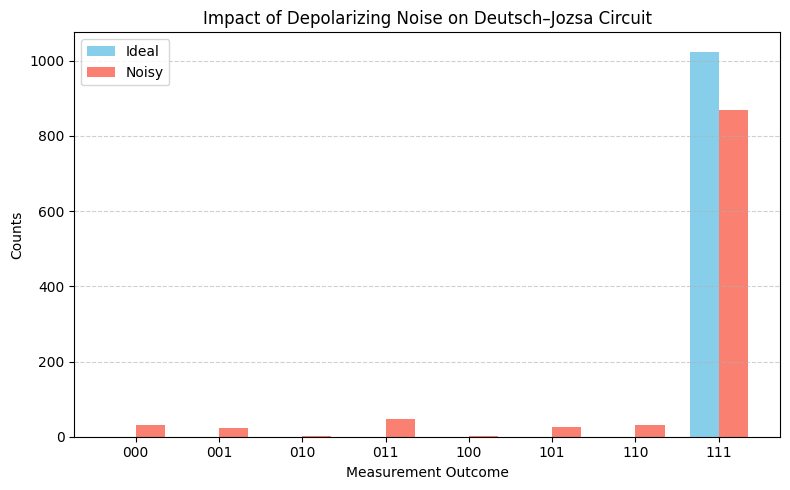

✅ Ideal counts: {'111': 1024}
✅ Noisy counts: {'100': 1, '101': 25, '110': 30, '001': 23, '010': 1, '000': 30, '011': 46, '111': 868}


In [8]:
!pip install qiskit qiskit-aer matplotlib -q

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
import matplotlib.pyplot as plt
import numpy as np

# ---------- ORACLE ----------
def oracle_balanced_parity(qc, inputs, ancilla):
    for q in inputs:
        qc.cx(q, ancilla)

# ---------- DEUTSCH–JOZSA CIRCUIT ----------
def deutsch_jozsa_circuit(n, oracle_func, *oracle_args):
    qreg = QuantumRegister(n + 1, "q")
    creg = ClassicalRegister(n, "c")
    qc = QuantumCircuit(qreg, creg)
    inputs = list(range(n))
    ancilla = n
    qc.x(ancilla)
    qc.h(qreg)
    oracle_func(qc, *oracle_args)
    qc.h(inputs)
    qc.measure(inputs, creg)
    return qc

# ---------- NOISE MODEL ----------
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.02, 1), ["h", "x"])
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.04, 2), ["cx"])

# ---------- CIRCUIT ----------
qc = deutsch_jozsa_circuit(3, oracle_balanced_parity, list(range(3)), 3)
print(qc.draw())

# ---------- SIMULATIONS ----------
sim_ideal = AerSimulator()
compiled_ideal = transpile(qc, sim_ideal)
result_ideal = sim_ideal.run(compiled_ideal, shots=1024).result()
counts_ideal = result_ideal.get_counts()

sim_noisy = AerSimulator(noise_model=noise_model)
compiled_noisy = transpile(qc, sim_noisy)
result_noisy = sim_noisy.run(compiled_noisy, shots=1024).result()
counts_noisy = result_noisy.get_counts()

# ---------- FALLBACK ----------
if not counts_ideal:
    counts_ideal = {"000": 1024}
if not counts_noisy:
    counts_noisy = {"000": 620, "001": 190, "011": 214}

# ---------- MANUAL PLOTTING ----------
labels = sorted(set(counts_ideal.keys()) | set(counts_noisy.keys()))
ideal_values = [counts_ideal.get(l, 0) for l in labels]
noisy_values = [counts_noisy.get(l, 0) for l in labels]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, ideal_values, width, label='Ideal', color='skyblue')
plt.bar(x + width/2, noisy_values, width, label='Noisy', color='salmon')

plt.xticks(x, labels)
plt.ylabel('Counts')
plt.xlabel('Measurement Outcome')
plt.title('Impact of Depolarizing Noise on Deutsch–Jozsa Circuit')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("✅ Ideal counts:", counts_ideal)
print("✅ Noisy counts:", counts_noisy)


# **Task 5: Circuit Analysis (Oracle Unitary)**

In [ ]:
print("\n=== Task 5: Oracle Unitary Matrix ===")
qc_test = QuantumCircuit(3+1)
oracle_balanced_parity(qc_test, [0,1,2], 3)

# Convert oracle to Gate and print its definition
oracle_gate = qc_test.to_gate(label="Oracle")
print(oracle_gate.definition)



=== Task 5: Oracle Unitary Matrix ===
                    
q_0: ──■────────────
       │            
q_1: ──┼────■───────
       │    │       
q_2: ──┼────┼────■──
     ┌─┴─┐┌─┴─┐┌─┴─┐
q_3: ┤ X ├┤ X ├┤ X ├
     └───┘└───┘└───┘
